In [4]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

# 1. Test 메타 데이터 로드
# 데이터가 data 폴더 안에 있다고 가정합니다.
test_meta = pd.read_csv("./data/test.csv")
print(f"총 Test 에피소드 수: {len(test_meta)}")

# 경로 확인용 (첫 번째 경로 출력)
first_path = test_meta['path'].iloc[0]
print(f"CSV 내부의 원본 경로 예시: {first_path}")

# 2. 데이터 로드
test_episodes = []

# (옵션) 전체 데이터가 너무 많으면 오래 걸리므로, 테스트를 위해 1000개만 샘플링
# 전체를 다 하려면 아래 .sample(1000)을 제거하세요.
sample_paths = test_meta['path'].sample(1000, random_state=42) 
# sample_paths = test_meta['path'] # 전체를 다 하려면 주석 해제

print("데이터 로딩 시작...")

success_count = 0
fail_count = 0

for path in tqdm(sample_paths, desc="Loading Test Samples"):
    try:
        # [핵심 수정] 경로 보정 로직
        # CSV에 있는 경로가 './test/...' 이고, 실제 파일이 './data/test/...' 라면 경로를 바꿔줘야 합니다.
        # 만약 코드가 있는 위치 기준으로 바로 './test' 폴더가 있다면 이 처리는 필요 없지만,
        # 현재 에러 상황을 보아 경로 수정이 필요해 보입니다.
        
        # 1. 만약 현재 실행 위치에 'test' 폴더가 없고 'data/test'에 있다면:
        real_path = path.replace("./test", "./data/test") 
        
        # 2. 혹은 단순히 파일명만 필요한 경우 (상황에 따라 주석 풀고 사용)
        # real_path = os.path.join("./data/test", path.split("/")[-2], path.split("/")[-1])

        df = pd.read_csv(real_path)
        test_episodes.append(df)
        success_count += 1
        
    except Exception as e:
        # 실패 시 원본 경로로 한번 더 시도 (혹시 경로 수정이 불필요했을 경우를 대비)
        try:
            df = pd.read_csv(path)
            test_episodes.append(df)
            success_count += 1
        except Exception as e2:
            fail_count += 1
            # 첫 번째 실패에 대해서만 에러 메시지 출력 (화면 도배 방지)
            if fail_count == 1:
                print(f"\n[Error] 파일을 찾을 수 없습니다.")
                print(f"시도한 경로 1: {real_path}")
                print(f"시도한 경로 2: {path}")
                print(f"에러 메시지: {e2}")

print(f"\n로딩 결과 - 성공: {success_count}, 실패: {fail_count}")

if len(test_episodes) > 0:
    # 하나의 큰 DataFrame으로 합치기
    test_df_sample = pd.concat(test_episodes, ignore_index=True)
    print(f"Sampled Test Rows: {test_df_sample.shape}")
    display(test_df_sample.head())
else:
    print("로드된 데이터가 없습니다. 파일 경로(폴더 구조)를 다시 확인해주세요.")

총 Test 에피소드 수: 2414
CSV 내부의 원본 경로 예시: ./test/153363/153363_1.csv
데이터 로딩 시작...


Loading Test Samples: 100%|██████████| 1000/1000 [00:00<00:00, 2012.02it/s]



로딩 결과 - 성공: 1000, 실패: 0
Sampled Test Rows: (22419, 15)


,game_id,period_id,episode_id,time_seconds,team_id,player_id,action_id,type_name,result_name,start_x,start_y,end_x,end_y,is_home,game_episode
0,153372,1,43,2730.033,4657,500472,1257,Pass_Corner,Unsuccessful,105.000000,68.000000,99.819405,34.952544,True,153372_43
1,153372,1,43,2731.433,4644,500515,1258,Duel,Successful,4.674002,32.995164,4.674002,32.995164,False,153372_43
2,153372,1,43,2731.433,4644,500515,1259,Interception,NaN,4.674002,32.995164,4.674002,32.995164,False,153372_43
3,153372,1,43,2731.433,4644,500515,1260,Clearance,NaN,4.674002,32.995164,19.269180,37.979360,False,153372_43
4,153372,1,43,2733.133,4657,500478,1261,Duel,Successful,85.730820,30.020640,98.653590,30.549884,True,153372_43


전체 데이터 수: 356721
고유 에피소드 수: 15435


,game_id,period_id,episode_id,time_seconds,team_id,player_id,action_id,type_name,result_name,start_x,start_y,end_x,end_y,is_home,game_episode
0,126283,1,1,0.667,2354,344559,0,Pass,Successful,52.418205,33.485444,31.322445,38.274752,True,126283_1
1,126283,1,1,3.667,2354,250036,2,Pass,Successful,32.013240,38.100808,37.371285,30.632980,True,126283_1
2,126283,1,1,4.968,2354,500145,4,Carry,NaN,37.371285,30.632980,38.391570,24.613144,True,126283_1
3,126283,1,1,8.200,2354,500145,5,Pass,Successful,38.391570,24.613144,34.573350,5.545468,True,126283_1
4,126283,1,1,11.633,2354,142106,7,Pass,Successful,34.578705,6.058256,21.274470,18.437112,True,126283_1


/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:61: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:61: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:61: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:61: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:61: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/

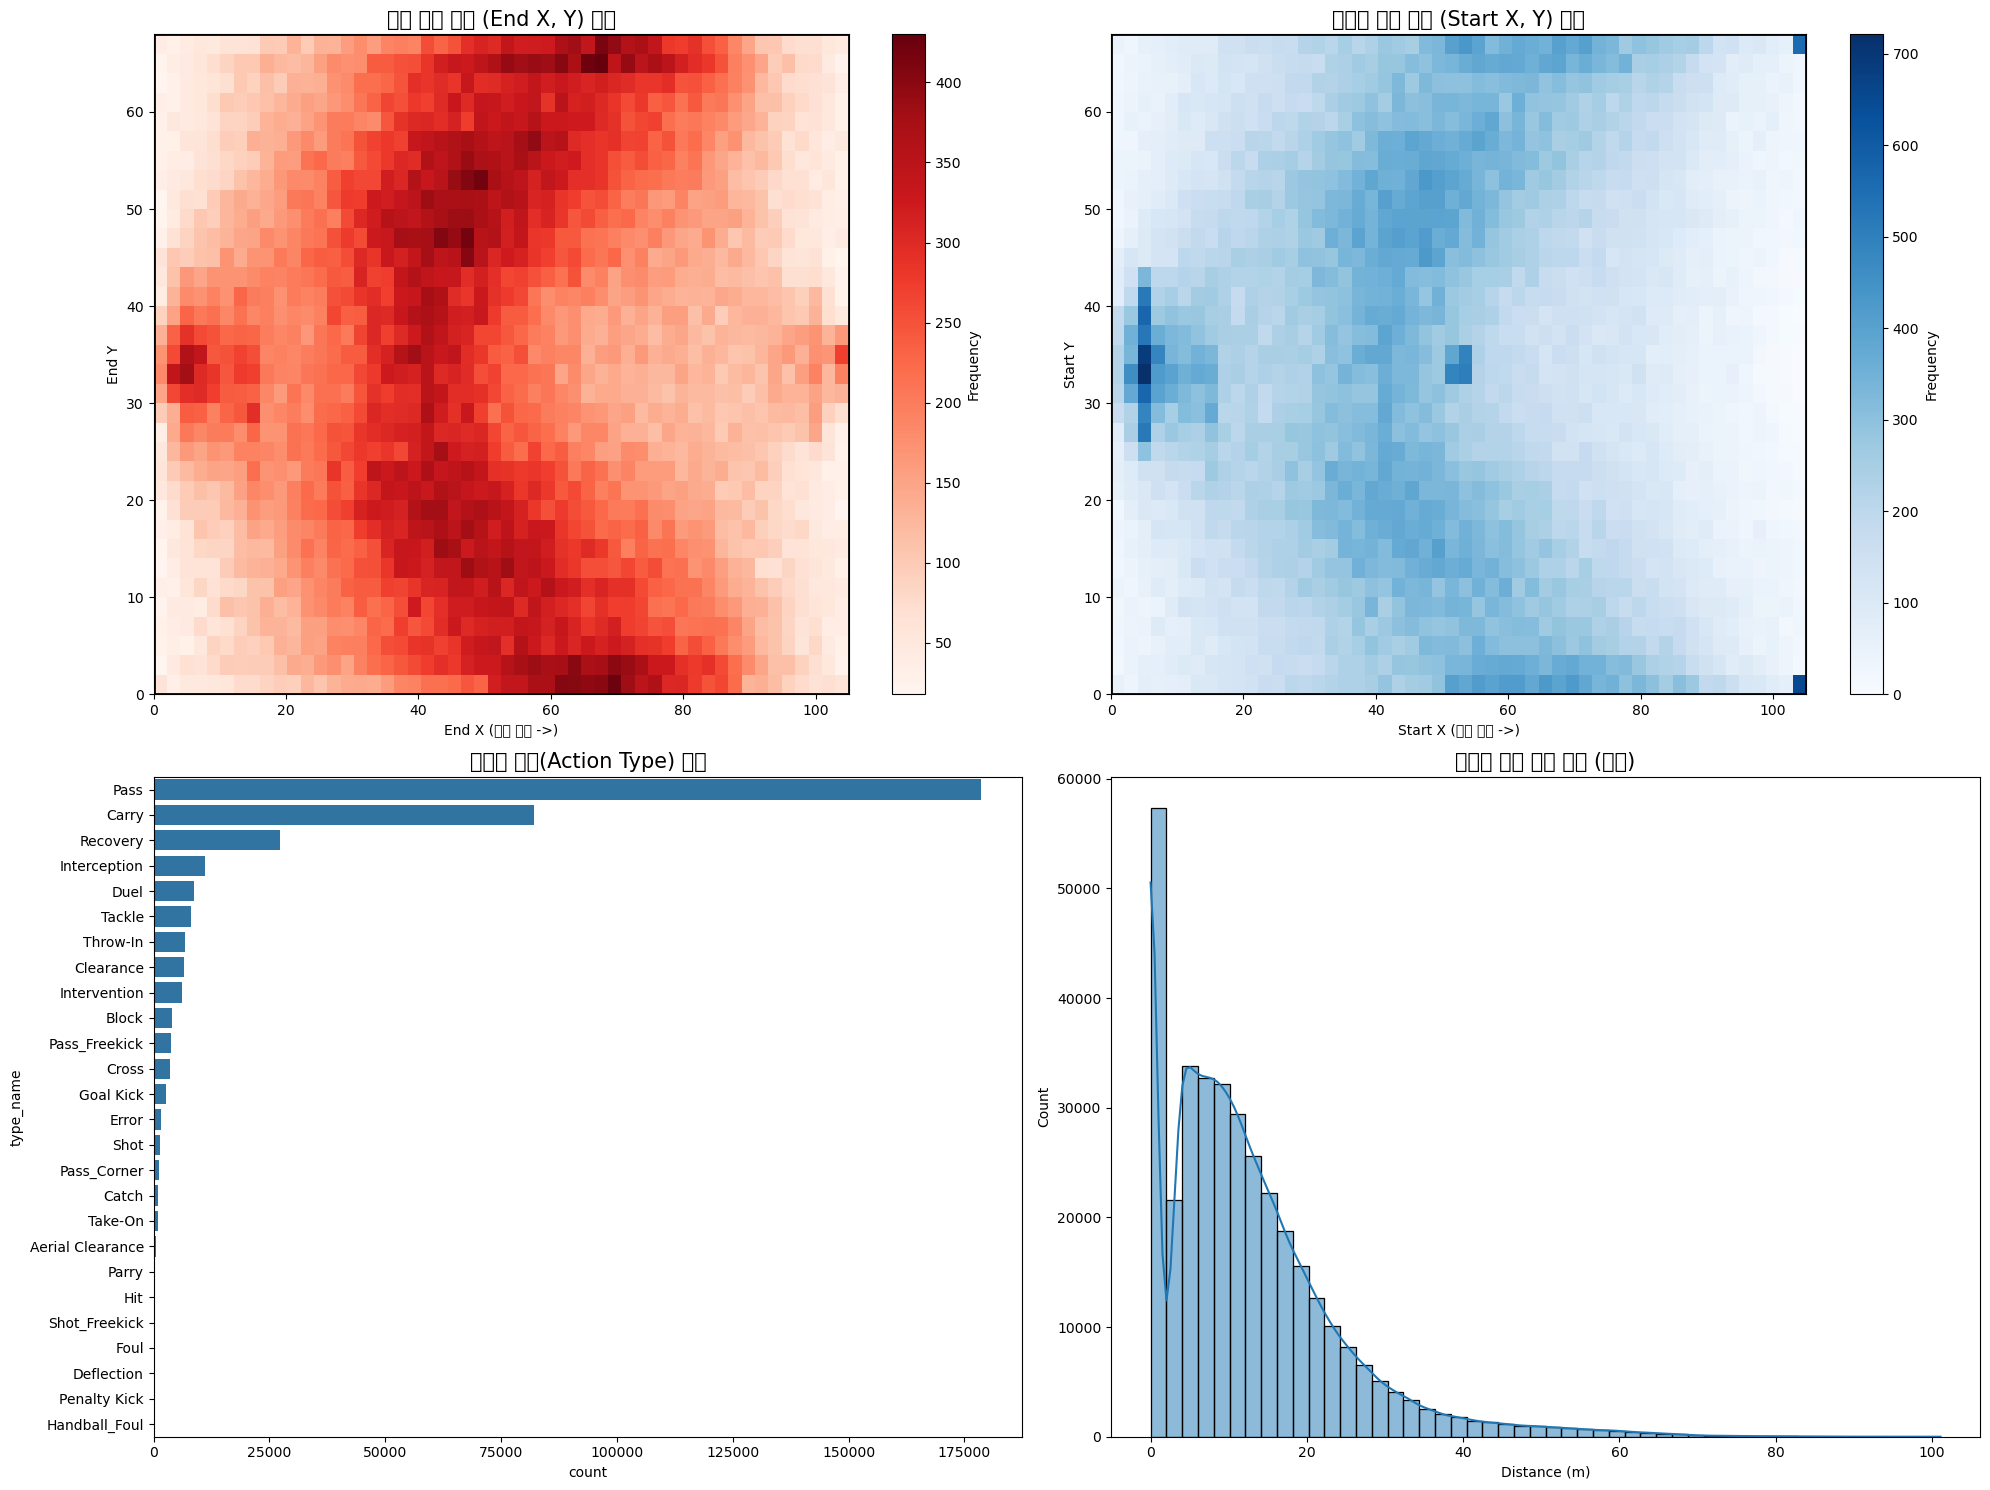

/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:81: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:81: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:81: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:81: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2225592420.py:81: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_

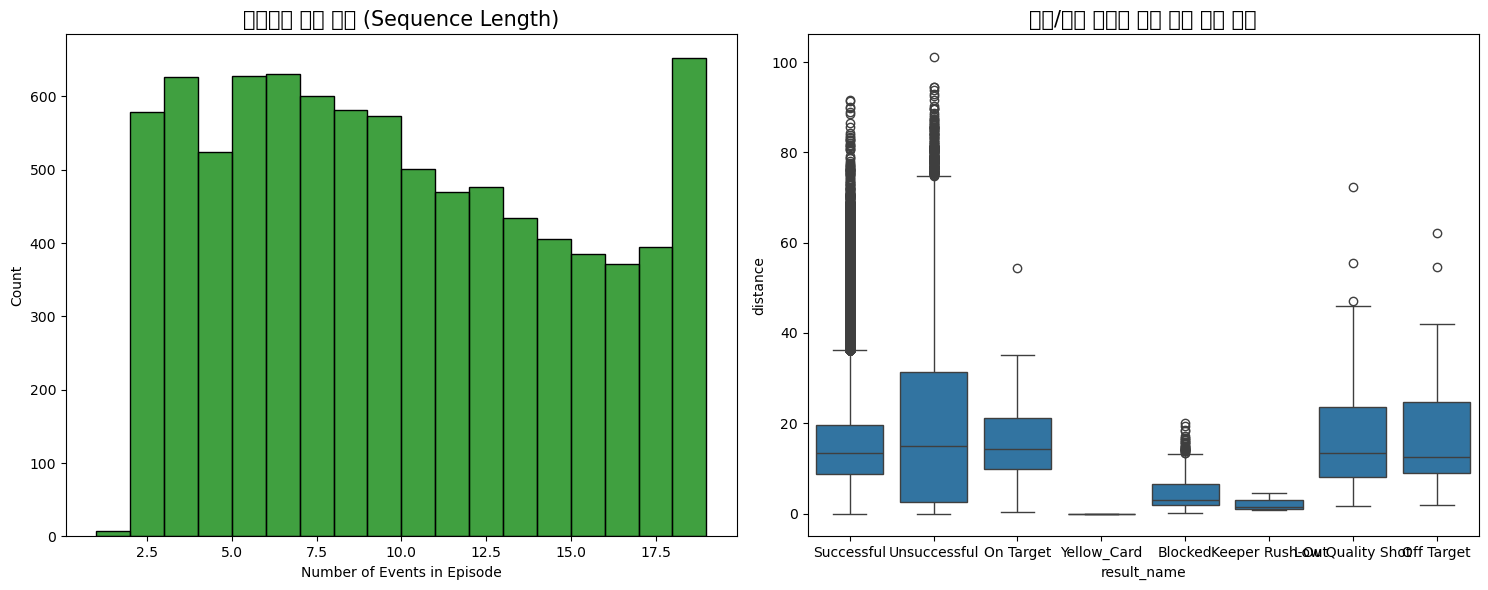

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48143 (\N{HANGUL SYLLABLE MIC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

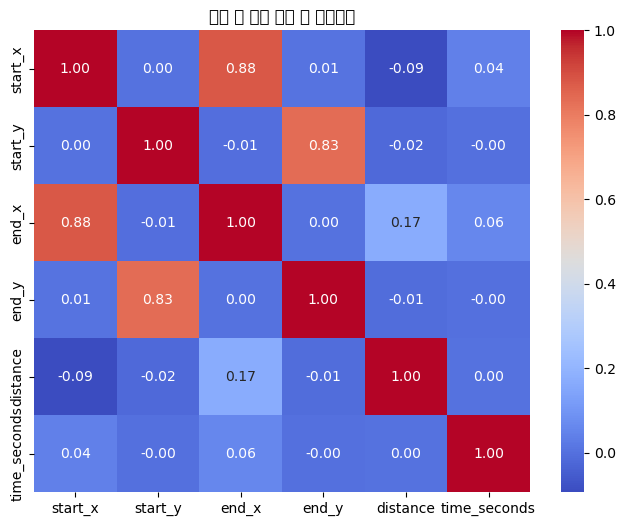

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# 1. 데이터 로드
# 파일 경로를 실제 경로에 맞게 수정해주세요.
train = pd.read_csv('./data/train.csv')
match_info = pd.read_csv('./data/match_info.csv')

# 데이터 기본 정보 확인
print(f"전체 데이터 수: {len(train)}")
print(f"고유 에피소드 수: {train['game_episode'].nunique()}")
display(train.head())

# ==========================================
# 2. 파생 변수 생성 (분석용)
# ==========================================
# 거리 및 각도 계산
train['dx'] = train['end_x'] - train['start_x']
train['dy'] = train['end_y'] - train['start_y']
train['distance'] = np.sqrt(train['dx']**2 + train['dy']**2)
train['angle'] = np.degrees(np.arctan2(train['dy'], train['dx'])) # -180 ~ 180도

# ==========================================
# 3. 데이터 시각화
# ==========================================
plt.figure(figsize=(20, 15))

# (1) 패스 도착 위치 (Target) 분포 - 히트맵
plt.subplot(2, 2, 1)
plt.hist2d(train['end_x'], train['end_y'], bins=[52, 34], range=[[0, 105], [0, 68]], cmap='Reds')
plt.colorbar(label='Frequency')
plt.title('패스 도착 위치 (End X, Y) 밀도', fontsize=15)
plt.xlabel('End X (공격 방향 ->)')
plt.ylabel('End Y')
# 경기장 라인 그리기 (간략)
plt.gca().add_patch(Rectangle((0, 0), 105, 68, fill=False, edgecolor='black', lw=2))

# (2) 이벤트 시작 위치 분포
plt.subplot(2, 2, 2)
plt.hist2d(train['start_x'], train['start_y'], bins=[52, 34], range=[[0, 105], [0, 68]], cmap='Blues')
plt.colorbar(label='Frequency')
plt.title('이벤트 시작 위치 (Start X, Y) 밀도', fontsize=15)
plt.xlabel('Start X (공격 방향 ->)')
plt.ylabel('Start Y')
plt.gca().add_patch(Rectangle((0, 0), 105, 68, fill=False, edgecolor='black', lw=2))

# (3) 이벤트 타입별 빈도수
plt.subplot(2, 2, 3)
sns.countplot(data=train, y='type_name', order=train['type_name'].value_counts().index)
plt.title('이벤트 타입(Action Type) 빈도', fontsize=15)

# (4) 이동 거리(Distance) 분포
plt.subplot(2, 2, 4)
sns.histplot(train['distance'], bins=50, kde=True)
plt.title('이벤트 이동 거리 분포 (미터)', fontsize=15)
plt.xlabel('Distance (m)')

plt.tight_layout()
plt.show()

# ==========================================
# 4. 상세 분석: 에피소드 길이 및 선수 패턴
# ==========================================
plt.figure(figsize=(15, 6))

# (1) 에피소드 길이 (하나의 에피소드에 몇 개의 이벤트가 있는가?)
episode_counts = train.groupby('game_episode').size()
plt.subplot(1, 2, 1)
sns.histplot(episode_counts, bins=range(1, 20), kde=False, color='green')
plt.title('에피소드 길이 분포 (Sequence Length)', fontsize=15)
plt.xlabel('Number of Events in Episode')

# (2) 성공/실패 여부에 따른 거리 차이
plt.subplot(1, 2, 2)
sns.boxplot(x='result_name', y='distance', data=train)
plt.title('성공/실패 여부에 따른 이동 거리 차이', fontsize=15)

plt.tight_layout()
plt.show()

# ==========================================
# 5. 상관관계 분석
# ==========================================
corr = train[['start_x', 'start_y', 'end_x', 'end_y', 'distance', 'time_seconds']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('좌표 및 주요 변수 간 상관관계')
plt.show()

전체 데이터 개수: 356721
총 에피소드 수: 15435
=== 데이터 샘플 ===


,game_id,period_id,episode_id,time_seconds,team_id,player_id,action_id,type_name,result_name,start_x,start_y,end_x,end_y,is_home,game_episode
0,126283,1,1,0.667,2354,344559,0,Pass,Successful,52.418205,33.485444,31.322445,38.274752,True,126283_1
1,126283,1,1,3.667,2354,250036,2,Pass,Successful,32.013240,38.100808,37.371285,30.632980,True,126283_1
2,126283,1,1,4.968,2354,500145,4,Carry,NaN,37.371285,30.632980,38.391570,24.613144,True,126283_1
3,126283,1,1,8.200,2354,500145,5,Pass,Successful,38.391570,24.613144,34.573350,5.545468,True,126283_1
4,126283,1,1,11.633,2354,142106,7,Pass,Successful,34.578705,6.058256,21.274470,18.437112,True,126283_1


/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2968555594.py:45: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2968555594.py:45: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2968555594.py:45: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2968555594.py:45: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ipykernel_11873/2968555594.py:45: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n0/b4ggg87x0ps67bsmkvz5zjp80000gn/T/ip

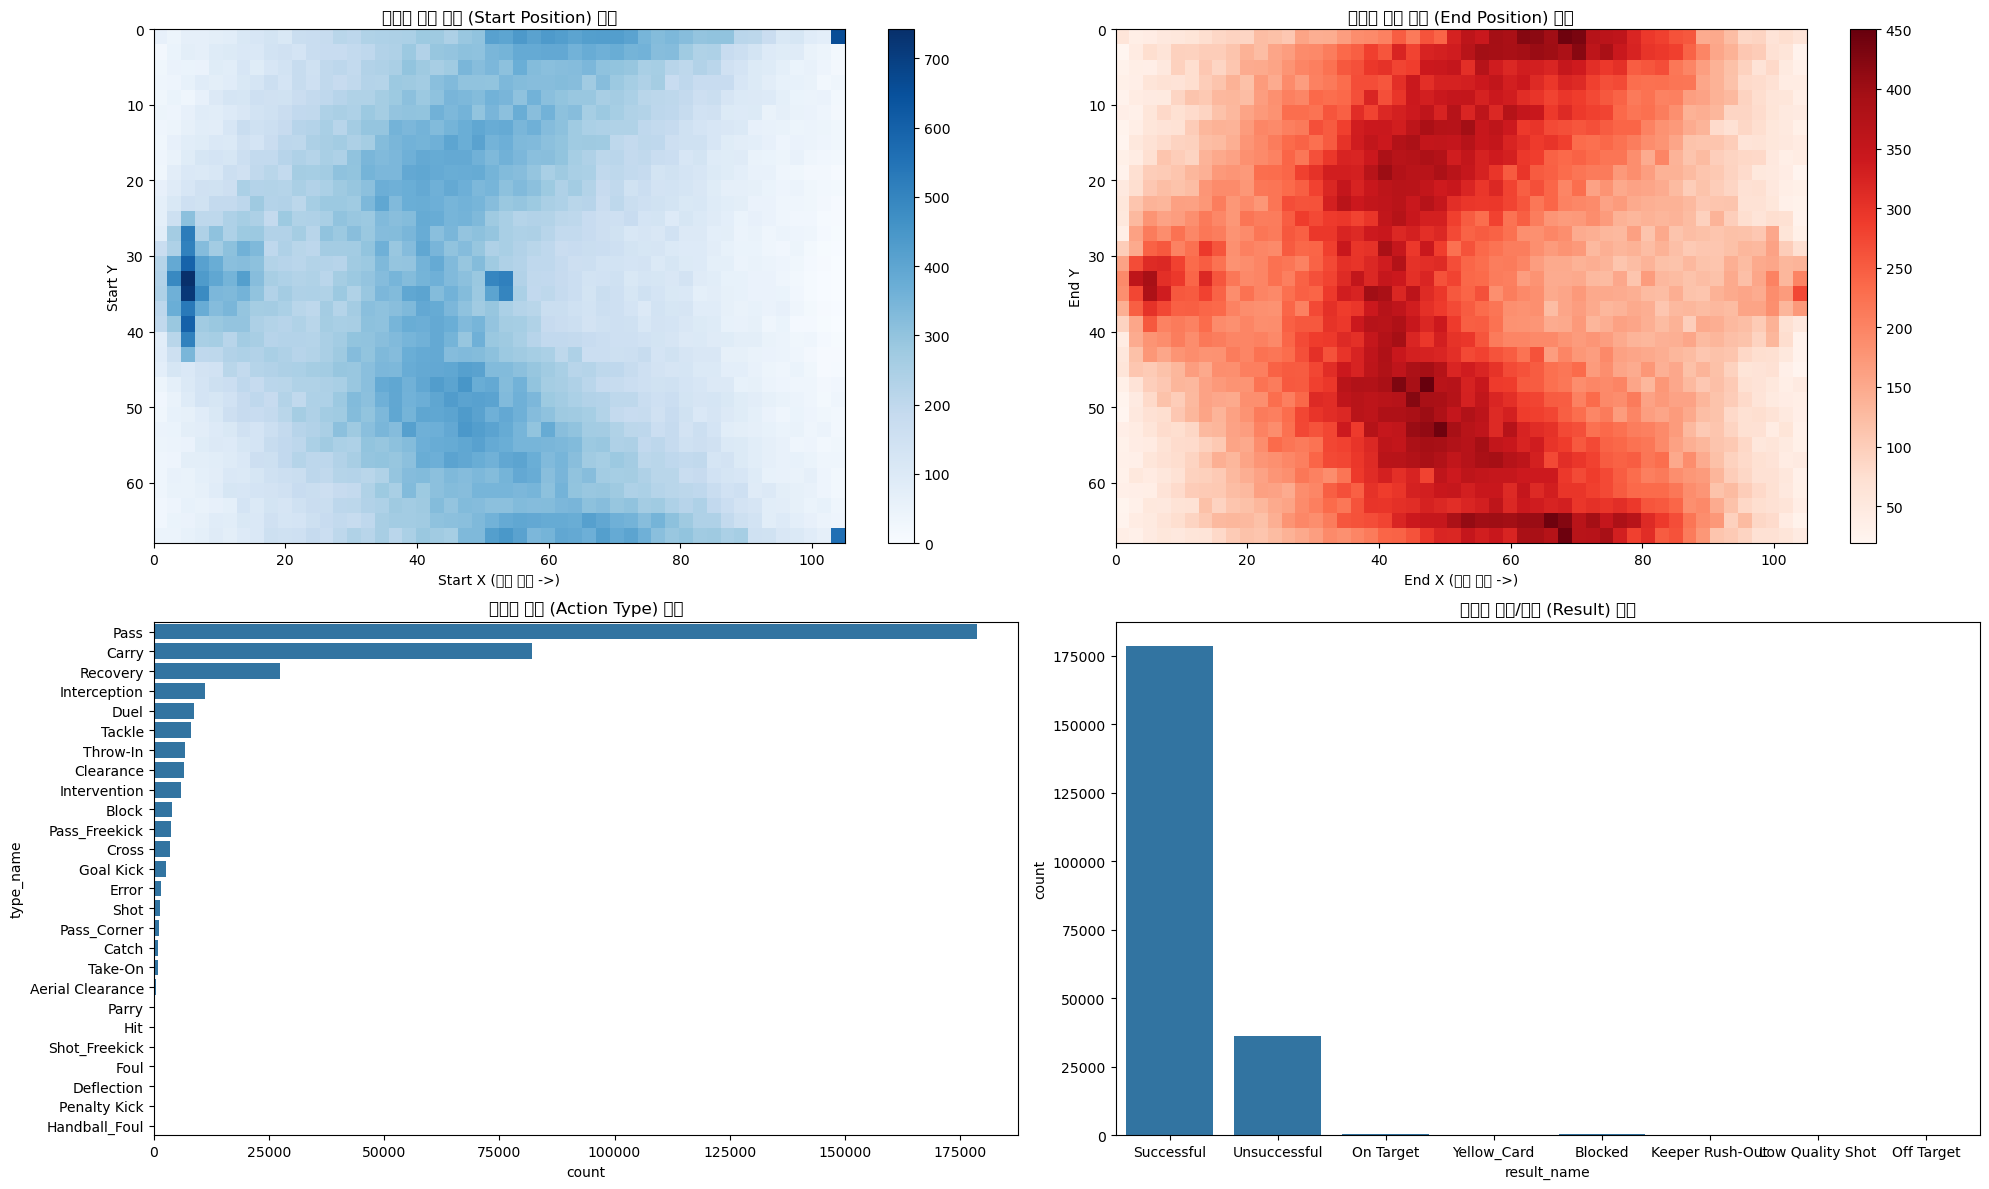

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48292 (\N{HANGUL SYLLABLE BEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(by

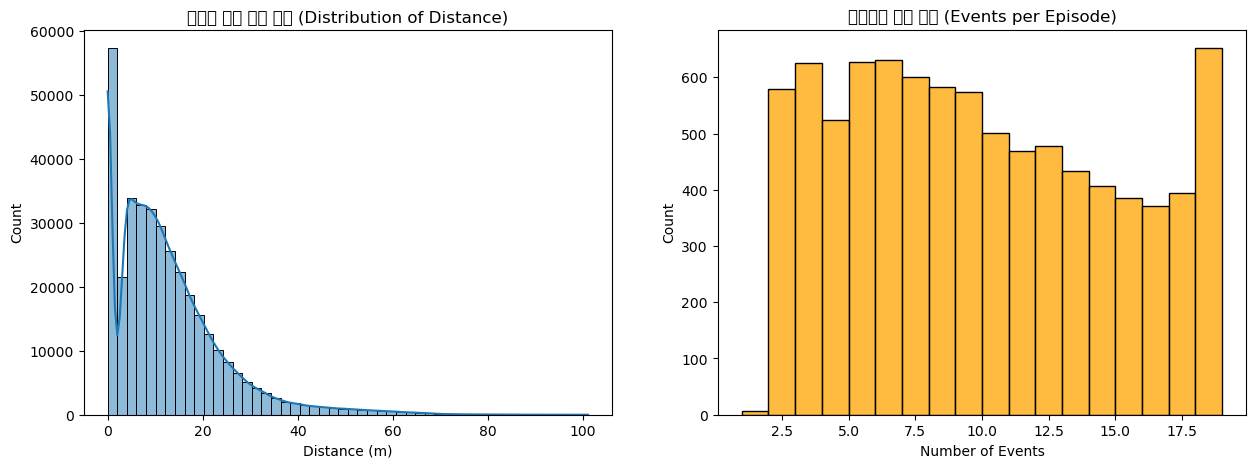

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 로드
df = pd.read_csv('./data/train.csv')

# 2. 기본 정보 확인
print(f"전체 데이터 개수: {len(df)}")
print(f"총 에피소드 수: {df['game_episode'].nunique()}")
print("=== 데이터 샘플 ===")
display(df.head())

# 3. 주요 시각화
plt.figure(figsize=(20, 12))

# (1) 패스/운반 시작 및 종료 위치 히트맵
plt.subplot(2, 2, 1)
plt.hist2d(df['start_x'], df['start_y'], bins=[50, 34], cmap='Blues', range=[[0, 105], [0, 68]])
plt.title('이벤트 시작 위치 (Start Position) 밀도')
plt.xlabel('Start X (공격 방향 ->)')
plt.ylabel('Start Y')
plt.colorbar()
plt.gca().invert_yaxis() # 축구장 좌표계(Y축) 반전

plt.subplot(2, 2, 2)
plt.hist2d(df['end_x'], df['end_y'], bins=[50, 34], cmap='Reds', range=[[0, 105], [0, 68]])
plt.title('이벤트 종료 위치 (End Position) 밀도')
plt.xlabel('End X (공격 방향 ->)')
plt.ylabel('End Y')
plt.colorbar()
plt.gca().invert_yaxis()

# (2) 이벤트 타입별 빈도
plt.subplot(2, 2, 3)
sns.countplot(data=df, y='type_name', order=df['type_name'].value_counts().index)
plt.title('이벤트 타입 (Action Type) 빈도')

# (3) 성공/실패 여부 분포
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='result_name')
plt.title('이벤트 성공/실패 (Result) 분포')

plt.tight_layout()
plt.show()

# 4. 심화 분석: 거리 및 각도 분포
# 거리(Distance) 계산
df['dx'] = df['end_x'] - df['start_x']
df['dy'] = df['end_y'] - df['start_y']
df['distance'] = np.sqrt(df['dx']**2 + df['dy']**2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['distance'], bins=50, kde=True)
plt.title('이벤트 이동 거리 분포 (Distribution of Distance)')
plt.xlabel('Distance (m)')

# 에피소드 길이(시퀀스 길이) 분포
episode_len = df.groupby('game_episode').size()
plt.subplot(1, 2, 2)
sns.histplot(episode_len, bins=range(1, 20), kde=False, color='orange')
plt.title('에피소드 길이 분포 (Events per Episode)')
plt.xlabel('Number of Events')
plt.show()